In [1]:
import tensorflow as tf
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow_datasets as tfds

In [2]:
train_ds = tfds.load('cats_vs_dogs', split='train[:20%]', shuffle_files=True)
test_ds = tfds.load('cats_vs_dogs', split='train[:20%]', shuffle_files=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.IUFS4C_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


Shape: (421, 484, 3)


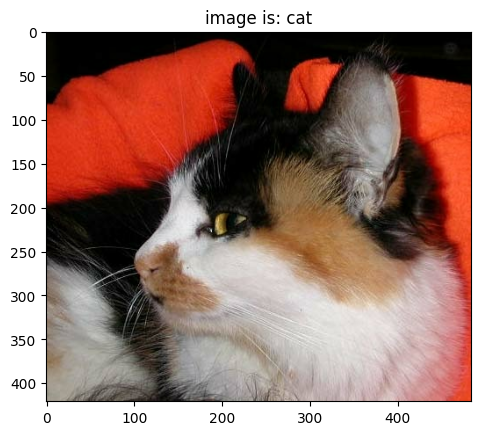

In [3]:
for example in train_ds.take(1):
  image = example['image']
  label = example['label']
  c_d = np.where(label.numpy() == 1, 'dog', 'cat')
  print(f'Shape: {image.shape}')
  plt.imshow(image.numpy())
  plt.title(f'image is: {c_d}')


In [4]:
 #preprocessing of the images
def preprocess(data):
  images = data['image']
  images = tf.image.resize(images, [224, 224])
  images = images/255.0
  return images, data['label']

train = train_ds.map(preprocess).batch(32)
test = test_ds.map(preprocess).batch(32)

In [5]:
inputs = keras.Input(shape=(224, 224, 3))
x = keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu')(inputs)
x = keras.layers.MaxPool2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=64, kernel_size=3, activation='relu')(x)
x = keras.layers.MaxPool2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu')(x)
x = keras.layers.MaxPool2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=256, kernel_size=3, activation='relu')(x)
x = keras.layers.MaxPool2D(pool_size=2)(x)
x = keras.layers.Conv2D(filters=516, kernel_size=3, activation='relu')(x)

x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 516)    │     1,189,380 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 51600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        51,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,629,397 (6.22 MB)

 Trainable params: 1,629,397 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
call_backs_list = [keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3
),
              keras.callbacks.ModelCheckpoint(
                  filepath='bestmodel.keras',
                  monitor='val_loss',
                  save_best_only=True
              )]



In [9]:
history =model.fit(
    train,
    epochs=20,
    batch_size=32,
    validation_data=test,
    callbacks= call_backs_list
)

Epoch 1/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 154ms/step - accuracy: 0.5630 - loss: 0.6715 - val_accuracy: 0.6225 - val_loss: 0.6648
Epoch 2/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.6371 - loss: 0.6484 - val_accuracy: 0.6829 - val_loss: 0.5985
Epoch 3/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 132ms/step - accuracy: 0.6584 - loss: 0.6158 - val_accuracy: 0.7210 - val_loss: 0.5638
Epoch 4/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.7173 - loss: 0.5569 - val_accuracy: 0.7517 - val_loss: 0.5139
Epoch 5/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 104ms/step - accuracy: 0.7644 - loss: 0.4992 - val_accuracy: 0.7790 - val_loss: 0.4655
Epoch 6/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.7885 - loss: 0.4498 - val_accuracy: 0.8143 - val_loss: 0.4098
Epoch 7/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 15s 101ms/step - accuracy: 0.8179 - loss: 0.4008 - val_accuracy: 0.8454 - val_loss: 0.3501
Epoch 8/20
146/146 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.8418 - loss: 0

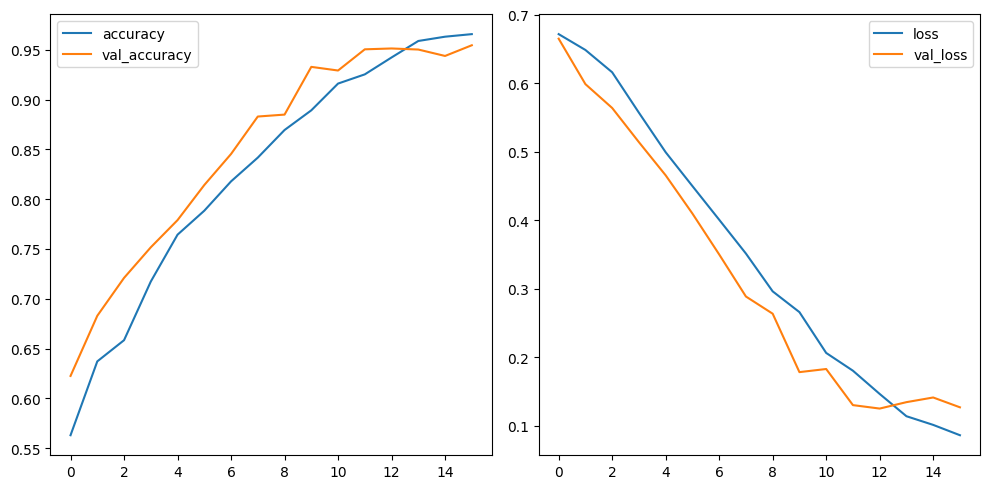

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].plot(history.epoch, history.history['accuracy'], label='accuracy')
axes[0].plot(history.epoch, history.history['val_accuracy'], label='val_accuracy')
axes[0].legend()
axes[1].plot(history.epoch, history.history['loss'], label='loss')
axes[1].plot(history.epoch, history.history['val_loss'], label='val_loss')
axes[1].legend()

fig.tight_layout()
plt.show()

In [11]:
model.evaluate(train)

146/146 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.9546 - loss: 0.1272


[0.1271631270647049, 0.954643189907074]

In [28]:
cat = Image.open('/content/images (2).webp')
dog = Image.open('/content/images.webp')
arr = np.asanyarray(cat)
arr_dog = np.asanyarray(dog)

(np.float64(-0.5), np.float64(553.5), np.float64(553.5), np.float64(-0.5))

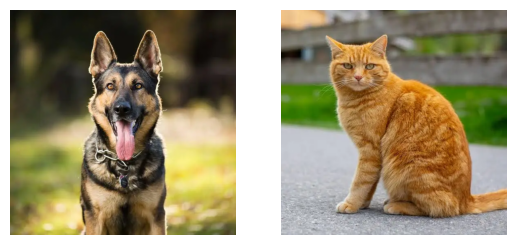

In [30]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(arr)
axes[0].axis('off')
axes[1].imshow(arr_dog)
axes[1].axis('off')

In [42]:
def process_image(pic):
  pic = tf.image.resize(pic, [224, 224])
  pic = tf.cast(pic, tf.float32)
  return tf.expand_dims(pic, axis=0)

img_cat = process_image(arr)
img_dog = process_image(arr_dog)


In [45]:
m = keras.models.load_model('/content/bestmodel.keras')